# load dataset

In [1]:
import pandas as pd
from tqdm import tqdm
import time
import pickle
from collections import Counter

# Display
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from skimage.transform import resize
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


files = os.listdir('./data')

In [2]:
import keras.backend as K

K.clear_session()

import logging
from tensorflow import keras
from keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalMaxPooling2D, Dropout, Conv2D, MaxPooling2D, Dense, Activation, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.utils import Sequence

# Only log error messages
tf.get_logger().setLevel(logging.ERROR)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
        


In [3]:
import tensorflow as tf
import keras
import numpy as np
import sklearn

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

TensorFlow version: 2.8.0
Keras version: 2.8.0
NumPy version: 1.23.1
Scikit-learn version: 1.1.0


In [4]:
dataset = pd.read_csv('./dataset.csv', index_col='Unnamed: 0')
dataset

,ALG13.KEGG_N_GLYCAN_BIOSYNTHESIS,DOLPP1.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG14.KEGG_N_GLYCAN_BIOSYNTHESIS,MAN1B1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG3.KEGG_N_GLYCAN_BIOSYNTHESIS,B4GALT1.KEGG_N_GLYCAN_BIOSYNTHESIS,MGAT5.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN2.KEGG_N_GLYCAN_BIOSYNTHESIS,STT3A.KEGG_N_GLYCAN_BIOSYNTHESIS,...,MYH7.KEGG_VIRAL_MYOCARDITIS,MYH6.KEGG_VIRAL_MYOCARDITIS,MYH9.KEGG_VIRAL_MYOCARDITIS,MYH8.KEGG_VIRAL_MYOCARDITIS,MYH11.KEGG_VIRAL_MYOCARDITIS,FYN.KEGG_VIRAL_MYOCARDITIS,MYH10.KEGG_VIRAL_MYOCARDITIS,HLA-DRB1.KEGG_VIRAL_MYOCARDITIS,HLA-DRA.KEGG_VIRAL_MYOCARDITIS,label
B3_P3_M15,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,4.65,0.0,0.00,0.00,0.0,9.13,14.14,1
B6_P1_M15,0.00,0.00,0.00,0.0,7.24,0.00,7.36,0.0,0.00,0.00,...,0.0,0.0,8.52,0.0,0.00,0.00,0.0,9.19,13.09,1
D7_P2_M15,9.07,0.00,7.61,0.0,0.00,7.61,7.69,0.0,0.00,6.24,...,0.0,0.0,5.95,0.0,0.00,0.00,0.0,11.46,13.66,1
E11_P2_M15,0.00,0.00,0.00,0.0,0.00,0.00,5.08,0.0,0.00,0.00,...,0.0,0.0,8.43,0.0,0.00,9.40,0.0,6.96,0.00,1
F7_P1_M15,0.00,0.00,7.50,0.0,0.00,0.00,7.23,0.0,9.21,8.24,...,0.0,0.0,8.33,0.0,0.00,4.77,0.0,8.28,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B10_P8_M86_L001,6.58,0.00,10.02,0.0,0.00,8.27,0.00,0.0,7.24,8.16,...,0.0,0.0,7.99,0.0,0.00,4.03,0.0,9.47,10.13,0
D1_P8_M86_L001,0.00,0.00,8.84,0.0,0.00,0.00,7.27,0.0,7.38,0.00,...,0.0,0.0,6.18,0.0,3.01,7.41,0.0,9.87,11.36,0
D7_P8_M86_L001,0.00,0.00,4.05,0.0,0.00,0.00,6.34,0.0,0.00,0.00,...,0.0,0.0,8.00,0.0,0.00,0.00,0.0,0.00,0.00,0
G7_P6_M86_L001,0.00,0.00,8.36,0.0,0.00,0.00,4.62,0.0,7.96,9.01,...,0.0,0.0,8.05,0.0,0.00,7.77,0.0,0.00,0.00,0


<AxesSubplot:xlabel='label'>

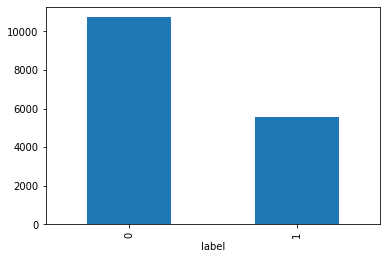

In [5]:
dataset.label.value_counts().plot(kind='bar')

In [6]:
print(dataset.groupby('label').size().reset_index(name = 'count'))

   label  count
0      0  10726
1      1   5564


In [7]:
print(dataset.isnull().values.any())

False


In [8]:
X = dataset.drop(['label'], axis=1)
y = dataset['label']

In [9]:
X

,ALG13.KEGG_N_GLYCAN_BIOSYNTHESIS,DOLPP1.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG14.KEGG_N_GLYCAN_BIOSYNTHESIS,MAN1B1.KEGG_N_GLYCAN_BIOSYNTHESIS,ALG3.KEGG_N_GLYCAN_BIOSYNTHESIS,B4GALT1.KEGG_N_GLYCAN_BIOSYNTHESIS,MGAT5.KEGG_N_GLYCAN_BIOSYNTHESIS,RPN2.KEGG_N_GLYCAN_BIOSYNTHESIS,STT3A.KEGG_N_GLYCAN_BIOSYNTHESIS,...,MYH4.KEGG_VIRAL_MYOCARDITIS,MYH7.KEGG_VIRAL_MYOCARDITIS,MYH6.KEGG_VIRAL_MYOCARDITIS,MYH9.KEGG_VIRAL_MYOCARDITIS,MYH8.KEGG_VIRAL_MYOCARDITIS,MYH11.KEGG_VIRAL_MYOCARDITIS,FYN.KEGG_VIRAL_MYOCARDITIS,MYH10.KEGG_VIRAL_MYOCARDITIS,HLA-DRB1.KEGG_VIRAL_MYOCARDITIS,HLA-DRA.KEGG_VIRAL_MYOCARDITIS
B3_P3_M15,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,4.65,0.0,0.00,0.00,0.0,9.13,14.14
B6_P1_M15,0.00,0.00,0.00,0.0,7.24,0.00,7.36,0.0,0.00,0.00,...,0.0,0.0,0.0,8.52,0.0,0.00,0.00,0.0,9.19,13.09
D7_P2_M15,9.07,0.00,7.61,0.0,0.00,7.61,7.69,0.0,0.00,6.24,...,0.0,0.0,0.0,5.95,0.0,0.00,0.00,0.0,11.46,13.66
E11_P2_M15,0.00,0.00,0.00,0.0,0.00,0.00,5.08,0.0,0.00,0.00,...,0.0,0.0,0.0,8.43,0.0,0.00,9.40,0.0,6.96,0.00
F7_P1_M15,0.00,0.00,7.50,0.0,0.00,0.00,7.23,0.0,9.21,8.24,...,0.0,0.0,0.0,8.33,0.0,0.00,4.77,0.0,8.28,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B10_P8_M86_L001,6.58,0.00,10.02,0.0,0.00,8.27,0.00,0.0,7.24,8.16,...,0.0,0.0,0.0,7.99,0.0,0.00,4.03,0.0,9.47,10.13
D1_P8_M86_L001,0.00,0.00,8.84,0.0,0.00,0.00,7.27,0.0,7.38,0.00,...,0.0,0.0,0.0,6.18,0.0,3.01,7.41,0.0,9.87,11.36
D7_P8_M86_L001,0.00,0.00,4.05,0.0,0.00,0.00,6.34,0.0,0.00,0.00,...,0.0,0.0,0.0,8.00,0.0,0.00,0.00,0.0,0.00,0.00
G7_P6_M86_L001,0.00,0.00,8.36,0.0,0.00,0.00,4.62,0.0,7.96,9.01,...,0.0,0.0,0.0,8.05,0.0,0.00,7.77,0.0,0.00,0.00


In [10]:
X.iloc[0,0]

0.0

In [11]:
y

B3_P3_M15          1
B6_P1_M15          1
D7_P2_M15          1
E11_P2_M15         1
F7_P1_M15          1
                  ..
B10_P8_M86_L001    0
D1_P8_M86_L001     0
D7_P8_M86_L001     0
G7_P6_M86_L001     0
H9_P9_M86_L001     0
Name: label, Length: 16290, dtype: int64

In [12]:
import pandas as pd

label = pd.read_csv('./patient.response.txt', sep='\t')
label

,characteristics,response,therapy
0,Post_P1,Responder,anti-PD1
1,Post_P1_2,Non-responder,anti-PD1
2,Pre_P2,Non-responder,anti-PD1
3,Post_P2,Non-responder,anti-PD1
4,Pre_P3,Non-responder,anti-PD1
5,Post_P3_2,Non-responder,anti-PD1
6,Pre_P4,Non-responder,anti-CTLA4+PD1
7,Post_P4,Responder,anti-CTLA4+PD1
8,Post_P5,Non-responder,anti-PD1
9,Post_P5_2,Responder,anti-PD1


In [13]:
label['response_therapy'] = label['response'].astype('str')+str('_')+label['therapy'].astype('str')
label

,characteristics,response,therapy,response_therapy
0,Post_P1,Responder,anti-PD1,Responder_anti-PD1
1,Post_P1_2,Non-responder,anti-PD1,Non-responder_anti-PD1
2,Pre_P2,Non-responder,anti-PD1,Non-responder_anti-PD1
3,Post_P2,Non-responder,anti-PD1,Non-responder_anti-PD1
4,Pre_P3,Non-responder,anti-PD1,Non-responder_anti-PD1
5,Post_P3_2,Non-responder,anti-PD1,Non-responder_anti-PD1
6,Pre_P4,Non-responder,anti-CTLA4+PD1,Non-responder_anti-CTLA4+PD1
7,Post_P4,Responder,anti-CTLA4+PD1,Responder_anti-CTLA4+PD1
8,Post_P5,Non-responder,anti-PD1,Non-responder_anti-PD1
9,Post_P5_2,Responder,anti-PD1,Responder_anti-PD1


In [14]:
label['response_therapy'].unique()

array(['Responder_anti-PD1', 'Non-responder_anti-PD1',
       'Non-responder_anti-CTLA4+PD1', 'Responder_anti-CTLA4+PD1',
       'Non-responder_anti-CTLA4', 'Responder_anti-CTLA4'], dtype=object)

# Modify dataset

## the number of pathway

In [15]:
gene = X.columns.str.split('.').str[0].tolist()
gene_unique = set(gene)
print('Gene 종류:', len(set(gene_unique)))

pathway = X.columns.str.split('.').str[1].tolist()
pathway_unique = set(pathway)
print('Pathway 종류:', len(set(pathway_unique)))

Gene 종류: 5030
Pathway 종류: 186


In [16]:
gene_pathway = pd.DataFrame({'gene':X.columns.str.split('.').str[0], 'pathway':X.columns.str.split('.').str[1]})
gene_pathway

,gene,pathway
0,ALG13,KEGG_N_GLYCAN_BIOSYNTHESIS
1,DOLPP1,KEGG_N_GLYCAN_BIOSYNTHESIS
2,RPN1,KEGG_N_GLYCAN_BIOSYNTHESIS
3,ALG14,KEGG_N_GLYCAN_BIOSYNTHESIS
4,MAN1B1,KEGG_N_GLYCAN_BIOSYNTHESIS
...,...,...
12408,MYH11,KEGG_VIRAL_MYOCARDITIS
12409,FYN,KEGG_VIRAL_MYOCARDITIS
12410,MYH10,KEGG_VIRAL_MYOCARDITIS
12411,HLA-DRB1,KEGG_VIRAL_MYOCARDITIS


In [17]:
#gene_pathway.to_csv("gene_pathway.csv", index=False)

In [18]:
for i in pathway_unique:
    if len(gene_pathway[gene_pathway['pathway']==i]) > 300:
        print((gene_pathway[gene_pathway['pathway']==i]))

         gene                      pathway
9019    CALM2  KEGG_OLFACTORY_TRANSDUCTION
9020    CALM1  KEGG_OLFACTORY_TRANSDUCTION
9021   OR11H4  KEGG_OLFACTORY_TRANSDUCTION
9022   OR52W1  KEGG_OLFACTORY_TRANSDUCTION
9023   OR5AU1  KEGG_OLFACTORY_TRANSDUCTION
...       ...                          ...
9397    OR2G6  KEGG_OLFACTORY_TRANSDUCTION
9398    OR6K3  KEGG_OLFACTORY_TRANSDUCTION
9399    OR6Y1  KEGG_OLFACTORY_TRANSDUCTION
9400  OR10AD1  KEGG_OLFACTORY_TRANSDUCTION
9401   OR4K15  KEGG_OLFACTORY_TRANSDUCTION

[383 rows x 2 columns]
         gene                  pathway
11008     JUN  KEGG_PATHWAYS_IN_CANCER
11009   STAT3  KEGG_PATHWAYS_IN_CANCER
11010     TFG  KEGG_PATHWAYS_IN_CANCER
11011   STAT1  KEGG_PATHWAYS_IN_CANCER
11012     HGF  KEGG_PATHWAYS_IN_CANCER
...       ...                      ...
11324   CKS1B  KEGG_PATHWAYS_IN_CANCER
11325     IL6  KEGG_PATHWAYS_IN_CANCER
11326   NTRK1  KEGG_PATHWAYS_IN_CANCER
11327  PIK3R1  KEGG_PATHWAYS_IN_CANCER
11328  PIK3R2  KEGG_PATHWAYS_IN

In [19]:
print('한 Pathway 당 가장 많은 gene 종류:', len(gene_pathway[gene_pathway['pathway']=='KEGG_OLFACTORY_TRANSDUCTION']))

한 Pathway 당 가장 많은 gene 종류: 383


In [20]:
print(383*186)

71238


## gene x pathway 2d

In [21]:
cell_list = X.index.to_list()
cell_list

['B3_P3_M15',
 'B6_P1_M15',
 'D7_P2_M15',
 'E11_P2_M15',
 'F7_P1_M15',
 'G11_P5_M15',
 'H10_P1_M15',
 'H2_P1_M15',
 'A7_P2_M15',
 'A9_P1_M15',
 'B2_P2_M15',
 'C11_P2_M15',
 'C6_P2_M15',
 'C6_P5_M15',
 'D12_P5_M15',
 'E1_P2_M15',
 'H10_P5_M15',
 'H7_P2_M15',
 'B10_P4_M15',
 'B3_P6_M15',
 'C11_P5_M15',
 'D10_P5_M15',
 'D1_P1_M15',
 'D6_P1_M15',
 'F2_P1_M15',
 'F6_P5_M15',
 'F8_P6_M15',
 'G12_P2_M15',
 'G1_P6_M15',
 'G3_P5_M15',
 'G7_P5_M15',
 'H1_P6_M15',
 'H3_P1_M15',
 'A10_P6_M15',
 'A12_P1_M15',
 'A12_P2_M15',
 'A4_P3_M15',
 'A8_P1_M15',
 'B3_P2_M15',
 'B4_P3_M15',
 'B7_P6_M15',
 'B9_P6_M15',
 'C10_P2_M15',
 'C2_P2_M15',
 'C4_P6_M15',
 'C5_P1_M15',
 'C8_P1_M15',
 'C9_P1_M15',
 'C9_P5_M15',
 'D6_P6_M15',
 'E11_P6_M15',
 'E12_P4_M15',
 'E1_P5_M15',
 'E4_P5_M15',
 'E6_P5_M15',
 'E8_P2_M15',
 'E9_P6_M15',
 'F11_P5_M15',
 'F12_P1_M15',
 'F12_P6_M14',
 'F3_P1_M15',
 'F7_P6_M15',
 'G10_P1_M15',
 'G10_P6_M15',
 'G3_P3_M15',
 'G6_P6_M15',
 'H11_P1_M15',
 'H12_P2_M15',
 'H12_P5_M15',
 'H12_P6_M

In [22]:
pathway_list = [
    'KEGG_RNA_DEGRADATION',
    'KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION',
    'KEGG_EPITHELIAL_CELL_SIGNALING_IN_HELICOBACTER_PYLORI_INFECTION',
    'KEGG_ASCORBATE_AND_ALDARATE_METABOLISM',
    'KEGG_GLYOXYLATE_AND_DICARBOXYLATE_METABOLISM',
    'KEGG_NOTCH_SIGNALING_PATHWAY',
    'KEGG_PROTEIN_EXPORT',
    'KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_DEGRADATION',
    'KEGG_MAPK_SIGNALING_PATHWAY',
    'KEGG_PROGESTERONE_MEDIATED_OOCYTE_MATURATION',
    'KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_LACTO_AND_NEOLACTO_SERIES',
    'KEGG_LEISHMANIA_INFECTION',
    'KEGG_PROSTATE_CANCER',
    'KEGG_TERPENOID_BACKBONE_BIOSYNTHESIS',
    'KEGG_FC_GAMMA_R_MEDIATED_PHAGOCYTOSIS',
    'KEGG_INOSITOL_PHOSPHATE_METABOLISM',
    'KEGG_VIBRIO_CHOLERAE_INFECTION',
    'KEGG_NICOTINATE_AND_NICOTINAMIDE_METABOLISM',
    'KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS',
    'KEGG_DRUG_METABOLISM_OTHER_ENZYMES',
    'KEGG_PRIMARY_IMMUNODEFICIENCY',
    'KEGG_RNA_POLYMERASE',
    'KEGG_NEUROTROPHIN_SIGNALING_PATHWAY',
    'KEGG_PANCREATIC_CANCER',
    'KEGG_CELL_ADHESION_MOLECULES_CAMS',
    'KEGG_ERBB_SIGNALING_PATHWAY',
    'KEGG_GLYCINE_SERINE_AND_THREONINE_METABOLISM',
    'KEGG_PENTOSE_PHOSPHATE_PATHWAY',
    'KEGG_CYTOSOLIC_DNA_SENSING_PATHWAY',
    'KEGG_STEROID_BIOSYNTHESIS',
    'KEGG_AUTOIMMUNE_THYROID_DISEASE',
    'KEGG_BASE_EXCISION_REPAIR',
    'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY',
    'KEGG_PARKINSONS_DISEASE',
    'KEGG_PPAR_SIGNALING_PATHWAY',
    'KEGG_PORPHYRIN_AND_CHLOROPHYLL_METABOLISM',
    'KEGG_MELANOMA',
    'KEGG_ABC_TRANSPORTERS',
    'KEGG_RIBOFLAVIN_METABOLISM',
    'KEGG_PYRUVATE_METABOLISM',
    'KEGG_VASOPRESSIN_REGULATED_WATER_REABSORPTION',
    'KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM',
    'KEGG_NON_HOMOLOGOUS_END_JOINING',
    'KEGG_RIBOSOME',
    'KEGG_ALPHA_LINOLENIC_ACID_METABOLISM',
    'KEGG_BASAL_TRANSCRIPTION_FACTORS',
    'KEGG_REGULATION_OF_AUTOPHAGY',
    'KEGG_ARRHYTHMOGENIC_RIGHT_VENTRICULAR_CARDIOMYOPATHY_ARVC',
    'KEGG_AMINOACYL_TRNA_BIOSYNTHESIS',
    'KEGG_PANTOTHENATE_AND_COA_BIOSYNTHESIS',
    'KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY',
    'KEGG_MATURITY_ONSET_DIABETES_OF_THE_YOUNG',
    'KEGG_HEMATOPOIETIC_CELL_LINEAGE',
    'KEGG_ALLOGRAFT_REJECTION',
    'KEGG_GAP_JUNCTION',
    'KEGG_RENAL_CELL_CARCINOMA',
    'KEGG_LIMONENE_AND_PINENE_DEGRADATION',
    'KEGG_SELENOAMINO_ACID_METABOLISM',
    'KEGG_DRUG_METABOLISM_CYTOCHROME_P450',
    'KEGG_RIG_I_LIKE_RECEPTOR_SIGNALING_PATHWAY',
    'KEGG_METABOLISM_OF_XENOBIOTICS_BY_CYTOCHROME_P450',
    'KEGG_NON_SMALL_CELL_LUNG_CANCER',
    'KEGG_NEUROACTIVE_LIGAND_RECEPTOR_INTERACTION',
    'KEGG_SPHINGOLIPID_METABOLISM',
    'KEGG_STARCH_AND_SUCROSE_METABOLISM',
    'KEGG_TIGHT_JUNCTION',
    'KEGG_CHRONIC_MYELOID_LEUKEMIA',
    'KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS',
    'KEGG_ENDOMETRIAL_CANCER',
    'KEGG_DNA_REPLICATION',
    'KEGG_REGULATION_OF_ACTIN_CYTOSKELETON',
    'KEGG_B_CELL_RECEPTOR_SIGNALING_PATHWAY',
    'KEGG_GRAFT_VERSUS_HOST_DISEASE',
    'KEGG_PRIMARY_BILE_ACID_BIOSYNTHESIS',
    'KEGG_PRION_DISEASES',
    'KEGG_GLYCOLYSIS_GLUCONEOGENESIS',
    'KEGG_LONG_TERM_DEPRESSION',
    'KEGG_PHENYLALANINE_METABOLISM',
    'KEGG_MELANOGENESIS',
    'KEGG_GLIOMA',
    'KEGG_MISMATCH_REPAIR',
    'KEGG_ARACHIDONIC_ACID_METABOLISM',
    'KEGG_TASTE_TRANSDUCTION',
    'KEGG_BETA_ALANINE_METABOLISM',
    'KEGG_SMALL_CELL_LUNG_CANCER',
    'KEGG_PROPANOATE_METABOLISM',
    'KEGG_ASTHMA',
    'KEGG_TGF_BETA_SIGNALING_PATHWAY',
    'KEGG_BASAL_CELL_CARCINOMA',
    'KEGG_ARGININE_AND_PROLINE_METABOLISM',
    'KEGG_NITROGEN_METABOLISM',
    'KEGG_AMINO_SUGAR_AND_NUCLEOTIDE_SUGAR_METABOLISM',
    'KEGG_CYSTEINE_AND_METHIONINE_METABOLISM',
    'KEGG_GLYCOSYLPHOSPHATIDYLINOSITOL_GPI_ANCHOR_BIOSYNTHESIS',
    'KEGG_VASCULAR_SMOOTH_MUSCLE_CONTRACTION',
    'KEGG_AXON_GUIDANCE',
    'KEGG_TYPE_II_DIABETES_MELLITUS',
    'KEGG_TYPE_I_DIABETES_MELLITUS',
    'KEGG_STEROID_HORMONE_BIOSYNTHESIS',
    'KEGG_N_GLYCAN_BIOSYNTHESIS',
    'KEGG_HISTIDINE_METABOLISM',
    'KEGG_GLYCOSAMINOGLYCAN_BIOSYNTHESIS_CHONDROITIN_SULFATE',
    'KEGG_CIRCADIAN_RHYTHM_MAMMAL',
    'KEGG_O_GLYCAN_BIOSYNTHESIS',
    'KEGG_INTESTINAL_IMMUNE_NETWORK_FOR_IGA_PRODUCTION',
    'KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY',
    'KEGG_PEROXISOME',
    'KEGG_WNT_SIGNALING_PATHWAY',
    'KEGG_HUNTINGTONS_DISEASE',
    'KEGG_OOCYTE_MEIOSIS',
    'KEGG_LINOLEIC_ACID_METABOLISM',
    'KEGG_P53_SIGNALING_PATHWAY',
    'KEGG_OTHER_GLYCAN_DEGRADATION',
    'KEGG_LONG_TERM_POTENTIATION',
    'KEGG_HOMOLOGOUS_RECOMBINATION',
    'KEGG_TAURINE_AND_HYPOTAURINE_METABOLISM',
    'KEGG_ADHERENS_JUNCTION',
    'KEGG_GLYCEROPHOSPHOLIPID_METABOLISM',
    'KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION',
    'KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_GLOBO_SERIES',
    'KEGG_PATHOGENIC_ESCHERICHIA_COLI_INFECTION',
    'KEGG_COLORECTAL_CANCER',
    'KEGG_APOPTOSIS',
    'KEGG_RETINOL_METABOLISM',
    'KEGG_HEDGEHOG_SIGNALING_PATHWAY',
    'KEGG_PYRIMIDINE_METABOLISM',
    'KEGG_FATTY_ACID_METABOLISM',
    'KEGG_GNRH_SIGNALING_PATHWAY',
    'KEGG_AMYOTROPHIC_LATERAL_SCLEROSIS_ALS',
    'KEGG_TYROSINE_METABOLISM',
    'KEGG_CARDIAC_MUSCLE_CONTRACTION',
    'KEGG_VIRAL_MYOCARDITIS',
    'KEGG_COMPLEMENT_AND_COAGULATION_CASCADES',
    'KEGG_CALCIUM_SIGNALING_PATHWAY',
    'KEGG_OLFACTORY_TRANSDUCTION',
    'KEGG_FC_EPSILON_RI_SIGNALING_PATHWAY',
    'KEGG_SULFUR_METABOLISM',
    'KEGG_SPLICEOSOME',
    'KEGG_CITRATE_CYCLE_TCA_CYCLE',
    'KEGG_LEUKOCYTE_TRANSENDOTHELIAL_MIGRATION',
    'KEGG_PATHWAYS_IN_CANCER',
    'KEGG_DORSO_VENTRAL_AXIS_FORMATION',
    'KEGG_PROXIMAL_TUBULE_BICARBONATE_RECLAMATION',
    'KEGG_ACUTE_MYELOID_LEUKEMIA',
    'KEGG_GLYCOSAMINOGLYCAN_BIOSYNTHESIS_HEPARAN_SULFATE',
    'KEGG_FOLATE_BIOSYNTHESIS',
    'KEGG_GLUTATHIONE_METABOLISM',
    'KEGG_GALACTOSE_METABOLISM',
    'KEGG_GLYCOSAMINOGLYCAN_DEGRADATION',
    'KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY',
    'KEGG_ALZHEIMERS_DISEASE',
    'KEGG_VEGF_SIGNALING_PATHWAY',
    'KEGG_ECM_RECEPTOR_INTERACTION',
    'KEGG_HYPERTROPHIC_CARDIOMYOPATHY_HCM',
    'KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS',
    'KEGG_MTOR_SIGNALING_PATHWAY',
    'KEGG_THYROID_CANCER',
    'KEGG_NOD_LIKE_RECEPTOR_SIGNALING_PATHWAY',
    'KEGG_FOCAL_ADHESION',
    'KEGG_OXIDATIVE_PHOSPHORYLATION',
    'KEGG_SNARE_INTERACTIONS_IN_VESICULAR_TRANSPORT',
    'KEGG_GLYCOSPHINGOLIPID_BIOSYNTHESIS_GANGLIO_SERIES',
    'KEGG_ETHER_LIPID_METABOLISM',
    'KEGG_LYSINE_DEGRADATION',
    'KEGG_GLYCEROLIPID_METABOLISM',
    'KEGG_CELL_CYCLE',
    'KEGG_BUTANOATE_METABOLISM',
    'KEGG_GLYCOSAMINOGLYCAN_BIOSYNTHESIS_KERATAN_SULFATE',
    'KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM',
    'KEGG_NUCLEOTIDE_EXCISION_REPAIR',
    'KEGG_TRYPTOPHAN_METABOLISM',
    'KEGG_ONE_CARBON_POOL_BY_FOLATE',
    'KEGG_RENIN_ANGIOTENSIN_SYSTEM',
    'KEGG_DILATED_CARDIOMYOPATHY',
    'KEGG_ENDOCYTOSIS',
    'KEGG_LYSOSOME',
    'KEGG_BIOSYNTHESIS_OF_UNSATURATED_FATTY_ACIDS',
    'KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION',
    'KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM',
    'KEGG_BLADDER_CANCER',
    'KEGG_INSULIN_SIGNALING_PATHWAY',
    'KEGG_CHEMOKINE_SIGNALING_PATHWAY',
    'KEGG_PROTEASOME',
    'KEGG_JAK_STAT_SIGNALING_PATHWAY',
    'KEGG_PURINE_METABOLISM',
    'KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS'
]

In [23]:
'''
# 저장
import pickle
with open("pathway_list.pkl", "wb") as f:
    pickle.dump(pathway_list, f)

# 다시 불러오기
with open("pathway_list.pkl", "rb") as f:
    pathway_list = pickle.load(f)
'''

'\n# 저장\nimport pickle\nwith open("pathway_list.pkl", "wb") as f:\n    pickle.dump(pathway_list, f)\n\n# 다시 불러오기\nwith open("pathway_list.pkl", "rb") as f:\n    pathway_list = pickle.load(f)\n'

In [24]:
# gene_matrix 초기화 (383 x 186)
gene_matrix = [[None for _ in range(len(pathway_list))] for _ in range(383)]

# 기준이 되는 한 cell (아무 cell이나 상관없음 — 순서만 필요)
cell = cell_list[0]

# 해당 cell에서 컬럼 정보 추출
cell_series = X.loc[cell]

for col_idx, pw in enumerate(pathway_list):
    # 이 pathway에 해당하는 컬럼 (gene.pathway 형식)
    cols_in_pw = cell_series[cell_series.index.str.contains(f"\.{pw}")].index.tolist()

    # gene 이름만 추출
    genes = [col.split('.')[0] for col in cols_in_pw]

    # 383개로 맞추기 (패딩)
    genes_padded = genes + [None] * (383 - len(genes))

    # gene_matrix에 저장
    for row_idx, gene in enumerate(genes_padded):
        gene_matrix[row_idx][col_idx] = gene

In [25]:
row = 9
col = 73

gene = gene_matrix[row][col]
pathway = pathway_list[col]

print(f"🔥 위치 ({row}, {col})는 Gene: {gene}, Pathway: {pathway}")


🔥 위치 (9, 73)는 Gene: HSD3B7, Pathway: KEGG_PRIMARY_BILE_ACID_BIOSYNTHESIS


In [26]:
gene_matrix_df = pd.DataFrame(gene_matrix, columns=pathway_list)
#gene_matrix_df.to_csv("gene_matrix_df.csv", index_label="Gene_Index")
gene_matrix_df

,KEGG_RNA_DEGRADATION,KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION,KEGG_EPITHELIAL_CELL_SIGNALING_IN_HELICOBACTER_PYLORI_INFECTION,KEGG_ASCORBATE_AND_ALDARATE_METABOLISM,KEGG_GLYOXYLATE_AND_DICARBOXYLATE_METABOLISM,KEGG_NOTCH_SIGNALING_PATHWAY,KEGG_PROTEIN_EXPORT,KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_DEGRADATION,KEGG_MAPK_SIGNALING_PATHWAY,KEGG_PROGESTERONE_MEDIATED_OOCYTE_MATURATION,...,KEGG_BIOSYNTHESIS_OF_UNSATURATED_FATTY_ACIDS,KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION,KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,KEGG_BLADDER_CANCER,KEGG_INSULIN_SIGNALING_PATHWAY,KEGG_CHEMOKINE_SIGNALING_PATHWAY,KEGG_PROTEASOME,KEGG_JAK_STAT_SIGNALING_PATHWAY,KEGG_PURINE_METABOLISM,KEGG_SYSTEMIC_LUPUS_ERYTHEMATOSUS
0,LSM5,HLA-DOA,JUN,UGT1A10,ACO1,HES5,IMMP1L,AOX1,JUN,CDC16,...,ACOT4,CCL26,MPI,HRAS,GCK,CCL26,PSMD11,STAT3,POLR2G,CD80
1,MPHOSPH6,HLA-DOB,JAM3,UGT1A8,GLYCTK,DTX3,SRP9P1,ALDH1B1,MEF2C,ADCY8,...,TECR,TNFSF13,PMM2,E2F1,CALM2,STAT3,PSMD12,STAT4,NT5C2,CD86
2,PATL1,KLRC3,ATP6V1G1,UGT1A7,MTHFD2,NOTCH4,SRP9,ACADS,ELK4,ADCY9,...,BAAT,HGF,PMM1,RAF1,PPARGC1A,STAT1,PSMC1P4,STAT1,POLR2H,CD28
3,EXOSC4,KLRD1,CHUK,UGT1A6,GRHPR,DTX3L,SRP14,ACADSB,ELK1,ADCY6,...,ELOVL5,CCL3L1,FBP2,EGFR,ELK1,STAT2,PSMD13,STAT2,ENPP3,FCGR1A
4,PNPT1,KLRC1,PTPN11,ALDH1B1,CS,NOTCH3,SEC61B,ABAT,JUND,RAF1,...,ELOVL6,TNFSF12,PFKM,CDKN2A,CALM1,CCL3L1,PSMB11,PIAS3,POLR2E,C9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
379,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
380,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
381,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [27]:
print(gene_matrix_df.iloc[9,73])

HSD3B7


In [28]:
'''
# gene x pathway 데이터프레임을 가진 cell list 만들기

dfs = []

for cell in tqdm(cell_list, desc='outer', position=0):
    df = pd.DataFrame(index=range(0,383), columns=pathway_list)
    
    for pw in pathway_list:
        temp = X.loc[cell][X.loc[cell].index.str.contains(pw)].values
        df[pw] = np.pad(temp, (0, 383-len(temp)), 'constant', constant_values=0)

    dfs.append(df)
'''


"\n# gene x pathway 데이터프레임을 가진 cell list 만들기\n\ndfs = []\n\nfor cell in tqdm(cell_list, desc='outer', position=0):\n    df = pd.DataFrame(index=range(0,383), columns=pathway_list)\n    \n    for pw in pathway_list:\n        temp = X.loc[cell][X.loc[cell].index.str.contains(pw)].values\n        df[pw] = np.pad(temp, (0, 383-len(temp)), 'constant', constant_values=0)\n\n    dfs.append(df)\n"

In [29]:
'''
# responder/nonresponder 폴더로 나누기

responder_path = '/home/taejoon/mount_ssd2/2023_scRNA/Responder/'
nonresponder_path = '/home/taejoon/mount_ssd2/2023_scRNA/Non_responder/'

for i in tqdm(range(len(dfs)), desc='outer', position=0):
    if y[i] == 1:
        dfs[i].to_csv(path_or_buf=responder_path+"{}.csv".format(y.index[i]))
    else:
        dfs[i].to_csv(path_or_buf=nonresponder_path+"{}.csv".format(y.index[i]))
'''


'\n# responder/nonresponder 폴더로 나누기\n\nresponder_path = \'/home/taejoon/mount_ssd2/2023_scRNA/Responder/\'\nnonresponder_path = \'/home/taejoon/mount_ssd2/2023_scRNA/Non_responder/\'\n\nfor i in tqdm(range(len(dfs)), desc=\'outer\', position=0):\n    if y[i] == 1:\n        dfs[i].to_csv(path_or_buf=responder_path+"{}.csv".format(y.index[i]))\n    else:\n        dfs[i].to_csv(path_or_buf=nonresponder_path+"{}.csv".format(y.index[i]))\n'

# load responder/non-responder dataset

In [30]:
responder_path = '/home/taejoon/mount_ssd2/2023/scRNA/Responder/'
nonresponder_path = '/home/taejoon/mount_ssd2/2023/scRNA/Non_responder/'

In [31]:
# responder cells 이름 리스트
responder_cells = os.listdir(responder_path)
print(responder_cells[:3])

# nonresponder cells 이름 리스트
nonresponder_cells = os.listdir(nonresponder_path)
print(nonresponder_cells[:3])

# 총 cells 개수
print('Responder cells: ', len(responder_cells))
print('Non-responder cells: ', len(nonresponder_cells))
print('Total cells: ', (len(responder_cells)+len(nonresponder_cells)))

['F12_P4_M47.csv', 'B9_P9_MMD5_L001.csv', 'D11_P7_M82_L001.csv']
['B12_P1_M39_T_enriched.csv', 'G6_P12_MMD2.36B_T_enriched.csv', 'F5_P5_M91_L001.csv']
Responder cells:  5564
Non-responder cells:  10726
Total cells:  16290


In [32]:
# responder cell numpy 형태로 변환

responder_cell_list_np = []

for i in tqdm(responder_cells):
    cell = pd.read_csv(f'./Responder/{i}', index_col='Unnamed: 0')
    cell_array = np.array(cell)
    responder_cell_list_np.append(cell_array)
    
X_responder = np.array(responder_cell_list_np)
print(X_responder.shape)

#np.save('X_responder.npy', X_responder)

y_responder = np.ones(5564, dtype='float64')
print(len(y_responder))


100%|██████████| 5564/5564 [00:47<00:00, 116.45it/s]


(5564, 383, 186)
5564


In [33]:
# nonresponder cell numpy 형태로 변환

nonresponder_cell_list_np = []

for i in tqdm(nonresponder_cells):
    cell = pd.read_csv(f'./Non_responder/{i}', index_col='Unnamed: 0')
    cell_array = np.array(cell)
    nonresponder_cell_list_np.append(cell_array)
    
X_nonresponder = np.array(nonresponder_cell_list_np)
print(X_nonresponder.shape)

#np.save('X_nonresponder.npy', X_nonresponder)

y_nonresponder = np.zeros(10726, dtype='float64')
print(len(y_nonresponder))


100%|██████████| 10726/10726 [01:44<00:00, 102.81it/s]


(10726, 383, 186)
10726


In [34]:
X = np.load('X.npy')
y = np.load('y.npy')

In [35]:
print(X.shape)
print(y.shape)

(16290, 383, 186)
(16290,)


## Train & Test split

In [36]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=25)

X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.2, shuffle=True, stratify=y_tr, random_state=25)

In [37]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(10425, 383, 186)
(3258, 383, 186)
(2607, 383, 186)


In [38]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(10425,)
(3258,)
(2607,)


In [39]:
#np.save("X_test_2d_cnn.npy", X_test)  # DataFrame → 배열로 저장
#np.save("y_test_2d_cnn.npy", y_test)  # Series → 배열로 저장

# Load Conv2D Model

In [40]:
from tensorflow.keras.models import load_model

model = load_model('best_model_gradcam.h5')


In [41]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test acc:', accuracy)

Test loss: 0.5246667265892029
Test acc: 0.7461633086204529


# Grad-CAM

* https://keras.io/examples/vision/grad_cam/ 
* https://hiddenbeginner.github.io/deeplearning/2022/02/15/tutorial_gradcam_tensorflow.html

In [42]:
'''
def make_grad_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()
'''

'\ndef make_grad_heatmap(img_array, model, last_conv_layer_name, pred_index=None):\n    grad_model = tf.keras.models.Model(\n        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]\n    )\n    \n    with tf.GradientTape() as tape:\n        last_conv_layer_output, preds = grad_model(img_array)\n        \n        if pred_index is None:\n            pred_index = tf.argmax(preds[0])\n        class_channel = preds[:, pred_index]\n        \n    grads = tape.gradient(class_channel, last_conv_layer_output)\n    \n    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))\n    \n    last_conv_layer_output = last_conv_layer_output[0]\n    \n    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]\n    heatmap = tf.squeeze(heatmap)\n    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)\n    return heatmap.numpy()\n'

In [43]:
def make_grad_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        # 중요: training=False로 명시
        last_conv_layer_output, preds = grad_model(img_array, training=False)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + 1e-8)  # NaN 방지
    
    return heatmap.numpy()


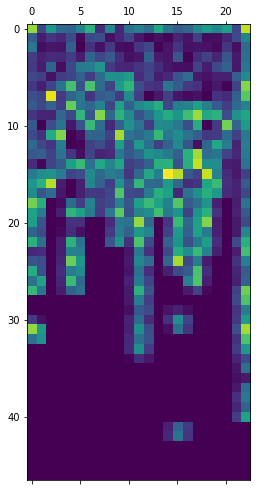

In [44]:
heatmap = make_grad_heatmap(X_val[0:1], model, 'max_pooling2d_2')
plt.matshow(heatmap)
plt.show()

In [45]:
def display_gradcam_with_img(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.uint8(superimposed_img)
    
    fig, axes = plt.subplots(1, 3, figsize=(15,10))
    axes[0].imshow(img)
    axes[1].imshow(heatmap)
    axes[2].imshow(superimposed_img)
    #for ax in axes:
        #ax.axis('off')

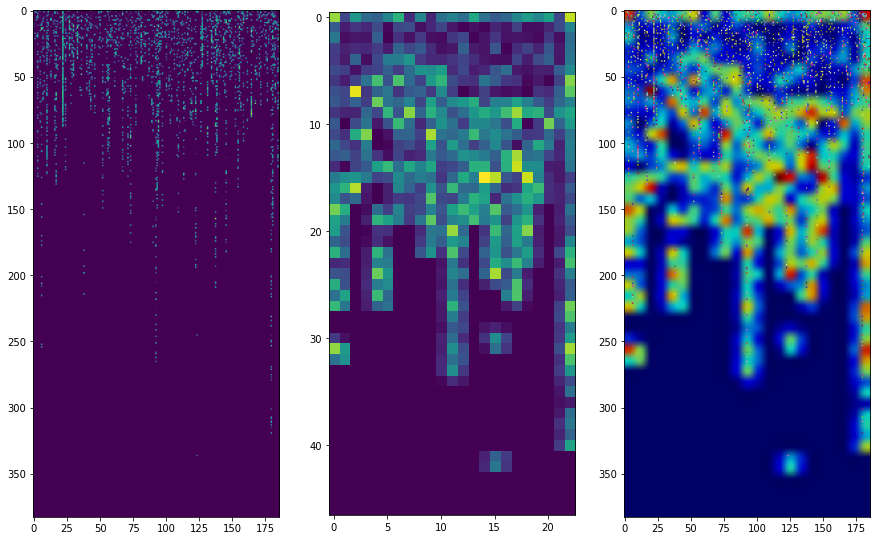

In [46]:
img = X_val[0].reshape(383,186,1)
heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')

k = display_gradcam_with_img(255 * img, heatmap, alpha=0.8)

## Responder heatmap

In [47]:
responder_dataframe = pd.read_excel('responder_dataframe.xlsx')
responder_dataframe

,cell,gene,pathway
0,F12_P4_M47,SKP2,KEGG_CELL_CYCLE
1,F12_P4_M47,PIK3R2,KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM
2,F12_P4_M47,CUL1,KEGG_CELL_CYCLE
3,F12_P4_M47,CALML6,KEGG_PHOSPHATIDYLINOSITOL_SIGNALING_SYSTEM
4,F12_P4_M47,SMAD3,KEGG_CELL_CYCLE
...,...,...,...
221178,B8_P1_M41_L001,ITGB6,KEGG_FOCAL_ADHESION
221179,B8_P1_M41_L001,ANAPC13,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS
221180,B8_P1_M41_L001,DOCK1,KEGG_FOCAL_ADHESION
221181,B8_P1_M41_L001,FBXO2,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS


In [48]:
responder_dataframe.value_counts(subset=['pathway','gene'], sort=True)[:30]

pathway                              gene  
KEGG_FOCAL_ADHESION                  COL4A2    630
KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS  CDC23     630
KEGG_FOCAL_ADHESION                  COL3A1    630
                                     BRAF      630
                                     COL4A4    630
KEGG_OXIDATIVE_PHOSPHORYLATION       COX11     630
                                     COX15     630
                                     CYC1      630
KEGG_FOCAL_ADHESION                  VAV1      630
                                     PDPK1     630
KEGG_OXIDATIVE_PHOSPHORYLATION       NDUFB4    630
                                     NDUFB5    630
KEGG_FOCAL_ADHESION                  PARVB     630
KEGG_OXIDATIVE_PHOSPHORYLATION       NDUFS2    630
                                     NDUFS3    630
                                     NDUFS5    630
KEGG_FOCAL_ADHESION                  COL4A1    630
KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS  CBLB      630
                                     A

100%|██████████| 5564/5564 [01:39<00:00, 55.87it/s]


✅ 저장 완료: responder_heatmap_average.pdf
✅ 저장 완료: responder_heatmap_average.svg


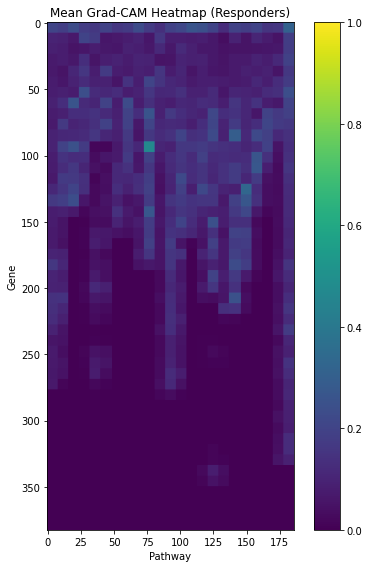

In [49]:
########### Responders' heatmap average ##############
heatmap_avg = np.empty(shape=(0,47,23))

for i in tqdm(range(len(X_responder))):
    img = X_responder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    
    heatmap_avg = np.vstack([heatmap_avg, heatmap[None,:]])
    
res_heatmap_avg = np.nanmean(heatmap_avg, axis=0)

im = Image.fromarray(res_heatmap_avg)
im = im.resize((186,383), Image.NEAREST)

res_heatmap = np.array(im)

# Heatmap 시각화
plt.figure(figsize=(6, 8))  # 필요시 크기 조절
plt.imshow(res_heatmap, vmin=0.0, vmax=1.0, cmap='viridis')
plt.colorbar()

# 축 레이블 추가
plt.xlabel("Pathway", fontsize=10)
plt.ylabel("Gene", fontsize=10)

# 제목 추가
plt.title("Mean Grad-CAM Heatmap (Responders)", fontsize=12)

plt.tight_layout()

# 저장 (PDF = 벡터 이미지)
plt.savefig("./vector_image/responder_heatmap_average.pdf", format='pdf')
plt.savefig("./vector_image/responder_heatmap_average.svg", format='svg')
print("✅ 저장 완료: responder_heatmap_average.pdf")
print("✅ 저장 완료: responder_heatmap_average.svg")

plt.show()
plt.close()

In [50]:
def get_gene_pathway_from_position(row, col, gene_matrix, pathway_list):
    """
    주어진 row, col 위치에서 gene 이름과 pathway 이름을 반환.
    """
    try:
        gene = gene_matrix[row][col]
        pathway = pathway_list[col]
    except IndexError:
        gene = None
        pathway = None
    return gene, pathway

In [51]:
def get_top_n_bright_spots(res_heatmap, gene_matrix, pathway_list, top_n=5):
    flat_idx = np.argsort(res_heatmap.ravel())[::-1]  # 전체 정렬 (나중에 필터링)
    top_coords = [np.unravel_index(idx, res_heatmap.shape) for idx in flat_idx]
    
    results = []
    for row, col in top_coords:
        gene, pathway = get_gene_pathway_from_position(row, col, gene_matrix, pathway_list)

        # 조건: gene 정보가 존재하는 경우만
        if gene is not None and str(gene).strip() != "":
            results.append((row, col, gene, pathway, res_heatmap[row, col]))

        if len(results) >= top_n:
            break  # 원하는 개수만큼만 추출
    
    return results

In [52]:
top_results = get_top_n_bright_spots(res_heatmap, gene_matrix, pathway_list, top_n=100)

# 정렬 기준: value 내림차순 → col 오름차순 → row 오름차순
sorted_results = sorted(
    top_results,
    key=lambda x: (-x[4], x[1], x[0])  # -value, col, row
)

# 출력
for row, col, gene, pathway, value in sorted_results:
    print(f"위치: (row={row}, col={col}) → Gene: {gene}, Pathway: {pathway}, 값: {value:.3f}")

위치: (row=90, col=78) → Gene: WNT3, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=91, col=78) → Gene: WNT5A, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=92, col=78) → Gene: CTNNB1, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=93, col=78) → Gene: WNT6, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=94, col=78) → Gene: FZD10, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=95, col=78) → Gene: CREB3L2, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=96, col=78) → Gene: FZD5, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=97, col=78) → Gene: TCF7L1, Pathway: KEGG_MELANOGENESIS, 값: 0.472
위치: (row=122, col=150) → Gene: IL1B, Pathway: KEGG_ALZHEIMERS_DISEASE, 값: 0.331
위치: (row=123, col=150) → Gene: SNCA, Pathway: KEGG_ALZHEIMERS_DISEASE, 값: 0.331
위치: (row=124, col=150) → Gene: MAPT, Pathway: KEGG_ALZHEIMERS_DISEASE, 값: 0.331
위치: (row=125, col=150) → Gene: NDUFB10, Pathway: KEGG_ALZHEIMERS_DISEASE, 값: 0.331
위치: (row=126, col=150) → Gene: NDUFS8, Pathway: KEGG_ALZHEIMERS_DISEASE, 값: 0.331
위치

In [53]:
def find_gene_position(gene_name, gene_matrix, pathway_list):
    for col, pathway in enumerate(pathway_list):
        for row in range(len(gene_matrix)):
            if gene_matrix[row][col] == gene_name:
                return row, col, pathway
    return None, None, None  # 못 찾은 경우

In [54]:
gene_to_find = "CCR7"
row, col, pathway = find_gene_position(gene_to_find, gene_matrix, pathway_list)

if row is not None:
    print(f"'{gene_to_find}' → 위치: (row={row}, col={col}), pathway: {pathway}")
else:
    print(f"'{gene_to_find}' 는 gene_matrix에 없음 (어떤 pathway에도 속하지 않음)")


'CCR7' → 위치: (row=192, col=177), pathway: KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION


✅ 저장 완료: ./vector_image/responder_heatmap_with_CCR7.pdf
✅ 저장 완료: ./vector_image/responder_heatmap_with_CCR7.svg


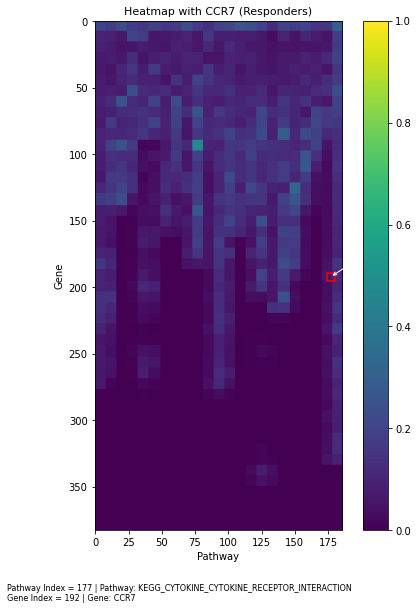

In [55]:
# Heatmap 시각화
plt.figure(figsize=(6, 8))
plt.imshow(res_heatmap, vmin=0.0, vmax=1.0, cmap='viridis')
plt.colorbar()

if row is not None:
    # 빈 네모 강조
    plt.plot(col, row, marker='s', markersize=8, markerfacecolor='none',
             markeredgecolor='red', markeredgewidth=1.5)

    # 화살표
    plt.annotate(
        text=gene_to_find,
        xy=(col, row),
        xytext=(col + 10, row - 10),
        textcoords='data',
        fontsize=8,
        color='white',
        arrowprops=dict(arrowstyle="->", color='white')
    )

    # ✅ gene/pathway 정보 → 아래쪽 여백에 출력
    info_text = f"Pathway Index = {col} | Pathway: {pathway}\nGene Index = {row} | Gene: {gene_to_find}"
    plt.figtext(0.01, -0.05, info_text, fontsize=8, ha='left')

# ✅ 축 이름은 따로 표시
plt.xlabel("Pathway", fontsize=10)
plt.ylabel("Gene", fontsize=10)

plt.title(f"Heatmap with {gene_to_find} (Responders)", fontsize=11)
plt.tight_layout()

# PDF 저장
save_path_pdf = f"./vector_image/responder_heatmap_with_{gene_to_find}.pdf"
plt.savefig(save_path_pdf, format='pdf', bbox_inches='tight')
print(f"✅ 저장 완료: {save_path_pdf}")

# SVG 저장
save_path_svg = save_path_pdf.replace(".pdf", ".svg")
plt.savefig(save_path_svg, format='svg', bbox_inches='tight')
print(f"✅ 저장 완료: {save_path_svg}")

plt.show()
plt.close()


In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_heatmap_with_single_arrow(heatmap, gene_matrix, pathway_list, top_n=5, save_path=None):
    top_results = get_top_n_bright_spots(heatmap, gene_matrix, pathway_list, top_n=top_n)
    sorted_results = sorted(top_results, key=lambda x: (-x[4], x[1], x[0]))

    # 🔧 2-패널 layout (왼쪽: heatmap, 오른쪽: 텍스트)
    fig = plt.figure(figsize=(10, 9))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.4)

    # 📊 Heatmap (왼쪽)
    ax0 = plt.subplot(gs[0])
    im = ax0.imshow(heatmap, vmin=0.0, vmax=1.0, cmap='viridis')
    ax0.set_xlabel("Pathway", fontsize=10)
    ax0.set_ylabel("Gene", fontsize=10)
    ax0.set_title(f"Top {top_n} Bright Spots", fontsize=12)
    plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)

    # ➤ 가장 밝은 위치 화살표 표시
    row, col, _, _, _ = sorted_results[0]
    ax0.annotate(
        text="",
        xy=(col, row),
        xytext=(col + 10, row - 10),
        textcoords='data',
        arrowprops=dict(arrowstyle="->", color='white')
    )

    # 📋 텍스트 정보 (오른쪽)
    ax1 = plt.subplot(gs[1])
    ax1.axis('off')
    text_lines = [
        f"Gene: {gene}\nPathway: {pathway}\nRow: {row}, Col: {col}\n"
        for row, col, gene, pathway, value in sorted_results
    ]
    info_text = "\n".join(text_lines)
    ax1.text(0, 1, info_text, fontsize=8, va='top', ha='left', wrap=True)

    if save_path:
        # PDF 저장
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path}")

        # SVG 저장 → 확장자만 바꿔서 저장
        save_path_svg = save_path.replace(".pdf", ".svg")
        plt.savefig(save_path_svg, format='svg', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path_svg}")

    plt.show()
    plt.close()

✅ 저장 완료: ./vector_image/responder_heatmap_arrows_only.pdf
✅ 저장 완료: ./vector_image/responder_heatmap_arrows_only.svg


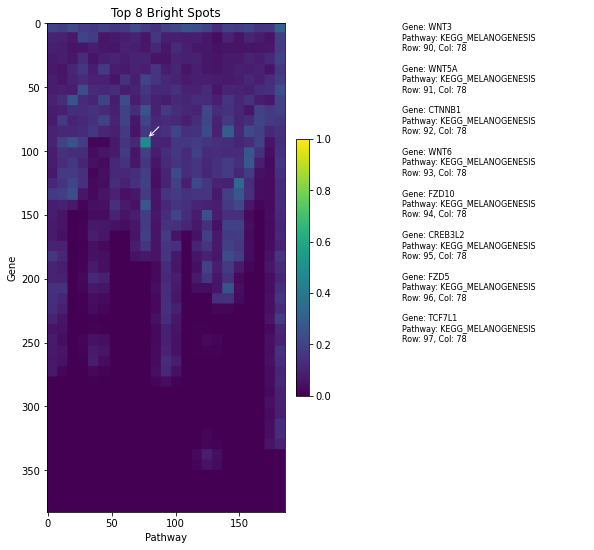

In [57]:
plot_heatmap_with_single_arrow(
    res_heatmap,
    gene_matrix,
    pathway_list,
    top_n=8,
    save_path="./vector_image/responder_heatmap_arrows_only.pdf"
)

## Non-responder heatmap

In [58]:
non_responder_dataframe = pd.read_excel('non_responder_dataframe.xlsx')
non_responder_dataframe

,cell,gene,pathway
0,B12_P1_M39_T_enriched,ADCY4,KEGG_DILATED_CARDIOMYOPATHY
1,B12_P1_M39_T_enriched,VPS4A,KEGG_ENDOCYTOSIS
2,B12_P1_M39_T_enriched,CTSV,KEGG_LYSOSOME
3,B12_P1_M39_T_enriched,CSF2,KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION
4,B12_P1_M39_T_enriched,TNNC1,KEGG_DILATED_CARDIOMYOPATHY
...,...,...,...
858075,D2_P4_M91_L001,ITGB6,KEGG_FOCAL_ADHESION
858076,D2_P4_M91_L001,ANAPC13,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS
858077,D2_P4_M91_L001,DOCK1,KEGG_FOCAL_ADHESION
858078,D2_P4_M91_L001,FBXO2,KEGG_UBIQUITIN_MEDIATED_PROTEOLYSIS


In [59]:
non_responder_dataframe.value_counts(subset=['pathway','gene'], sort=True)[:30]

pathway                                            gene   
KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION        CSF1       10726
                                                   CSF1R      10726
KEGG_NEUROACTIVE_LIGAND_RECEPTOR_INTERACTION       C3AR1      10726
                                                   AGTR2      10726
                                                   AGTR1      10726
KEGG_METABOLISM_OF_XENOBIOTICS_BY_CYTOCHROME_P450  UGT2A1     10726
                                                   UGT1A9     10726
                                                   GSTO2      10726
                                                   DHDH       10726
                                                   CYP3A43    10726
                                                   ALDH3B2    10726
                                                   ALDH3B1    10726
                                                   ALDH1A3    10726
KEGG_LYSOSOME                                      HGSNAT

100%|██████████| 10726/10726 [05:00<00:00, 35.66it/s]


✅ 저장 완료: non_responder_heatmap_average.pdf
✅ 저장 완료: non_responder_heatmap_average.svg


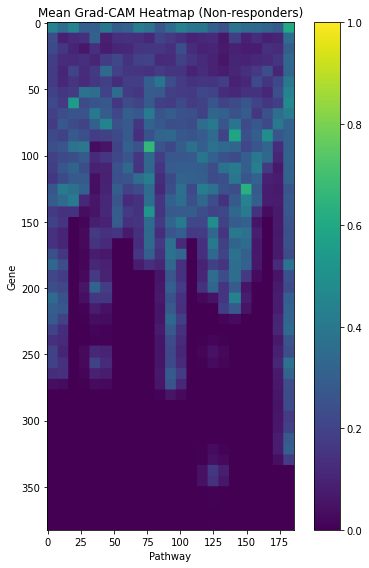

In [60]:
########### Non-responders' heatmap average ##############
heatmap_avg = np.empty(shape=(0,47,23))

for i in tqdm(range(len(X_nonresponder))):
    img = X_nonresponder[i].reshape(383,186,1)
    heatmap = make_grad_heatmap(img[np.newaxis], model, 'max_pooling2d_2')
    
    heatmap_avg = np.vstack([heatmap_avg, heatmap[None,:]])
    
non_heatmap_avg = np.nanmean(heatmap_avg, axis=0)

im = Image.fromarray(non_heatmap_avg)
im = im.resize((186,383), Image.NEAREST)

non_heatmap = np.array(im)

# Heatmap 시각화
plt.figure(figsize=(6, 8))  # 필요시 크기 조절
plt.imshow(non_heatmap, vmin=0.0, vmax=1.0, cmap='viridis')
plt.colorbar()

# 축 레이블 추가
plt.xlabel("Pathway", fontsize=10)
plt.ylabel("Gene", fontsize=10)

# 제목 추가
plt.title("Mean Grad-CAM Heatmap (Non-responders)", fontsize=12)

plt.tight_layout()

# 저장 (PDF = 벡터 이미지)
plt.savefig("./vector_image/non_responder_heatmap_average.pdf", format='pdf')
plt.savefig("./vector_image/non_responder_heatmap_average.svg", format='svg')
print("✅ 저장 완료: non_responder_heatmap_average.pdf")
print("✅ 저장 완료: non_responder_heatmap_average.svg")

plt.show()
plt.close()

In [61]:
top_results = get_top_n_bright_spots(non_heatmap, gene_matrix, pathway_list, top_n=8)

# 정렬 기준: value 내림차순 → col 오름차순 → row 오름차순
sorted_results = sorted(
    top_results,
    key=lambda x: (-x[4], x[1], x[0])  # -value, col, row
)

# 출력
for row, col, gene, pathway, value in sorted_results:
    print(f"위치: (row={row}, col={col}) → Gene: {gene}, Pathway: {pathway}, 값: {value:.3f}")

위치: (row=90, col=78) → Gene: WNT3, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=91, col=78) → Gene: WNT5A, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=92, col=78) → Gene: CTNNB1, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=93, col=78) → Gene: WNT6, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=94, col=78) → Gene: FZD10, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=95, col=78) → Gene: CREB3L2, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=96, col=78) → Gene: FZD5, Pathway: KEGG_MELANOGENESIS, 값: 0.667
위치: (row=97, col=78) → Gene: TCF7L1, Pathway: KEGG_MELANOGENESIS, 값: 0.667


In [62]:
gene_to_find = "CCR7"
row, col, pathway = find_gene_position(gene_to_find, gene_matrix, pathway_list)

if row is not None:
    print(f"'{gene_to_find}' → 위치: (row={row}, col={col}), pathway: {pathway}")
else:
    print(f"'{gene_to_find}' 는 gene_matrix에 없음 (어떤 pathway에도 속하지 않음)")

'CCR7' → 위치: (row=192, col=177), pathway: KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION


✅ 저장 완료: ./vector_image/non_responder_heatmap_with_CCR7.pdf
✅ 저장 완료: ./vector_image/non_responder_heatmap_with_CCR7.svg


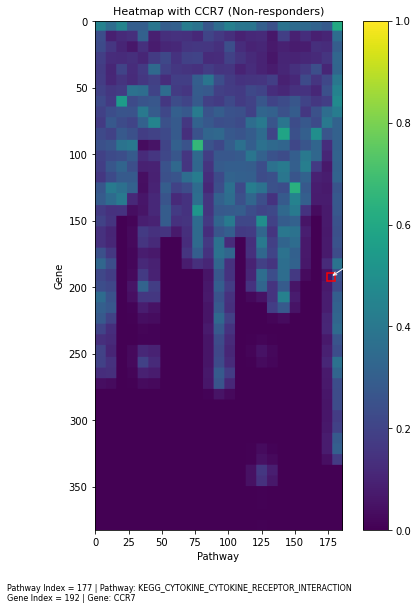

In [63]:
# Heatmap 시각화
plt.figure(figsize=(6, 8))
plt.imshow(non_heatmap, vmin=0.0, vmax=1.0, cmap='viridis')
plt.colorbar()

if row is not None:
    # 빈 네모 강조
    plt.plot(col, row, marker='s', markersize=8, markerfacecolor='none',
             markeredgecolor='red', markeredgewidth=1.5)

    # 화살표
    plt.annotate(
        text=gene_to_find,
        xy=(col, row),
        xytext=(col + 10, row - 10),
        textcoords='data',
        fontsize=8,
        color='white',
        arrowprops=dict(arrowstyle="->", color='white')
    )

    # ✅ gene/pathway 정보 → 아래쪽 여백에 출력
    info_text = f"Pathway Index = {col} | Pathway: {pathway}\nGene Index = {row} | Gene: {gene_to_find}"
    plt.figtext(0.01, -0.05, info_text, fontsize=8, ha='left')

# ✅ 축 이름은 따로 표시
plt.xlabel("Pathway", fontsize=10)
plt.ylabel("Gene", fontsize=10)

plt.title(f"Heatmap with {gene_to_find} (Non-responders)", fontsize=11)
plt.tight_layout()

# PDF 저장
save_path_pdf = f"./vector_image/non_responder_heatmap_with_{gene_to_find}.pdf"
plt.savefig(save_path_pdf, format='pdf', bbox_inches='tight')
print(f"✅ 저장 완료: {save_path_pdf}")

# SVG 저장
save_path_svg = save_path_pdf.replace(".pdf", ".svg")
plt.savefig(save_path_svg, format='svg', bbox_inches='tight')
print(f"✅ 저장 완료: {save_path_svg}")

plt.show()
plt.close()

✅ 저장 완료: ./vector_image/non_responder_heatmap_arrows_only.pdf
✅ 저장 완료: ./vector_image/non_responder_heatmap_arrows_only.svg


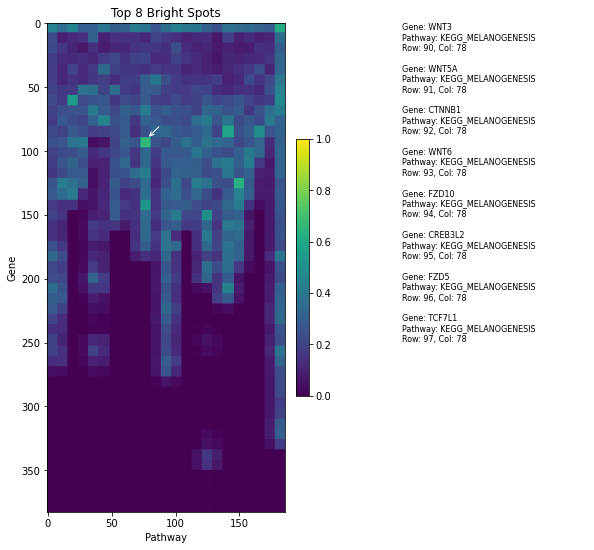

In [64]:
plot_heatmap_with_single_arrow(
    non_heatmap,
    gene_matrix,
    pathway_list,
    top_n=8,
    save_path="./vector_image/non_responder_heatmap_arrows_only.pdf"
)

## Difference

In [65]:
heatmap_diff = res_heatmap - non_heatmap
heatmap_diff

array([[-0.2383669, -0.2383669, -0.2383669, ..., -0.2971512, -0.2971512,
        -0.2971512],
       [-0.2383669, -0.2383669, -0.2383669, ..., -0.2971512, -0.2971512,
        -0.2971512],
       [-0.2383669, -0.2383669, -0.2383669, ..., -0.2971512, -0.2971512,
        -0.2971512],
       ...,
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ]], dtype=float32)

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap_diff(heatmap_res, heatmap_nonres, save_path=None):
    # 차이 계산
    heatmap_diff = heatmap_res - heatmap_nonres

    # 시각화
    plt.figure(figsize=(6, 8))
    plt.imshow(heatmap_diff, cmap='bwr', vmin=-np.max(np.abs(heatmap_diff)), vmax=np.max(np.abs(heatmap_diff)))
    plt.colorbar(label="Responder - Non-responder")

    plt.title("Grad-CAM Difference Heatmap", fontsize=12)
    plt.xlabel("Pathway")
    plt.ylabel("Gene")
    plt.tight_layout()

    if save_path:
        # PDF 저장
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path}")

        # SVG 저장 → 확장자만 바꿔서 저장
        save_path_svg = save_path.replace(".pdf", ".svg")
        plt.savefig(save_path_svg, format='svg', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path_svg}")
    
    plt.show()
    plt.close()

    return heatmap_diff  # 혹시 나중에 사용할 수 있도록 반환


✅ 저장 완료: ./vector_image/gradcam_diff_heatmap.pdf
✅ 저장 완료: ./vector_image/gradcam_diff_heatmap.svg


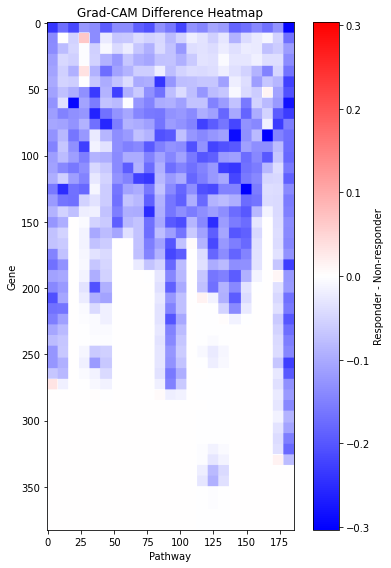

In [67]:
heatmap_diff = plot_heatmap_diff(
    res_heatmap,
    non_heatmap,
    save_path="./vector_image/gradcam_diff_heatmap.pdf"
)


In [68]:
def get_top_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=10):
    # 절댓값 기준으로 정렬
    flat_idx = np.argsort(np.abs(heatmap_diff).ravel())[::-1]
    top_coords = [np.unravel_index(idx, heatmap_diff.shape) for idx in flat_idx]

    results = []
    for row, col in top_coords:
        gene = gene_matrix[row][col]
        pathway = pathway_list[col]
        value = heatmap_diff[row, col]

        # ✅ gene과 pathway 둘 다 존재할 때만 추가
        if gene is not None and str(gene).strip() != "" and str(pathway).strip() != "":
            results.append((row, col, gene, pathway, value))

        if len(results) >= top_n:
            break

    return results

In [69]:
top_diff = get_top_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=9)

for row, col, gene, pathway, value in top_diff:
    print(f"Gene: {gene}, Pathway: {pathway}, Row: {row}, Col: {col}, Diff: {value:.3f}")

Gene: CDC23, Pathway: KEGG_CELL_CYCLE, Row: 85, Col: 165, Diff: -0.303
Gene: CHEK2, Pathway: KEGG_CELL_CYCLE, Row: 84, Col: 165, Diff: -0.303
Gene: EP300, Pathway: KEGG_CELL_CYCLE, Row: 86, Col: 165, Diff: -0.303
Gene: GSK3B, Pathway: KEGG_CELL_CYCLE, Row: 87, Col: 165, Diff: -0.303
Gene: ANAPC4, Pathway: KEGG_CELL_CYCLE, Row: 81, Col: 165, Diff: -0.303
Gene: SMAD2, Pathway: KEGG_CELL_CYCLE, Row: 82, Col: 165, Diff: -0.303
Gene: YWHAQ, Pathway: KEGG_CELL_CYCLE, Row: 83, Col: 165, Diff: -0.303
Gene: CDKN1C, Pathway: KEGG_CELL_CYCLE, Row: 89, Col: 165, Diff: -0.303
Gene: CDKN2A, Pathway: KEGG_CELL_CYCLE, Row: 88, Col: 165, Diff: -0.303


In [70]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_diff_heatmap_with_top_genes(heatmap_diff, gene_matrix, pathway_list, top_n=10, save_path=None):
    # 절댓값 기준으로 정렬
    flat_idx = np.argsort(np.abs(heatmap_diff).ravel())[::-1]
    top_coords = [np.unravel_index(idx, heatmap_diff.shape) for idx in flat_idx]

    results = []
    for row, col in top_coords:
        gene = gene_matrix[row][col]
        pathway = pathway_list[col]
        value = heatmap_diff[row, col]

        if gene is not None and str(gene).strip() != "" and str(pathway).strip() != "":
            results.append((row, col, gene, pathway, value))
        if len(results) >= top_n:
            break

    # 🔧 그리드 기반 레이아웃 설정
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.3)

    # Heatmap (왼쪽)
    ax0 = plt.subplot(gs[0])
    vmax = np.max(np.abs(heatmap_diff))
    im = ax0.imshow(heatmap_diff, cmap='bwr', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
    ax0.set_title("Grad-CAM Difference Heatmap", fontsize=12)
    ax0.set_xlabel("Pathway")
    ax0.set_ylabel("Gene")

    # ➤ 화살표 1개만 표시 (가장 큰 차이 위치)
    row, col, _, _, _ = results[0]
    ax0.annotate(
        "", xy=(col, row), xytext=(col + 10, row - 10),
        textcoords='data',
        arrowprops=dict(arrowstyle="->", color='red')
    )

    # 텍스트 리스트 (오른쪽)
    ax1 = plt.subplot(gs[1])
    ax1.axis('off')
    text_lines = [f"Gene: {gene}\nPathway: {pathway}\nRow: {row}, Col: {col}, Diff: {value:.3f}\n"
                  for row, col, gene, pathway, value in results]
    full_text = "\n".join(text_lines)
    ax1.text(0, 1, full_text, va='top', ha='left', fontsize=8, wrap=True)

    if save_path:
        # PDF 저장
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path}")

        # SVG 저장 → 확장자만 바꿔서 저장
        save_path_svg = save_path.replace(".pdf", ".svg")
        plt.savefig(save_path_svg, format='svg', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path_svg}")

    plt.show()
    plt.close()

    return results

✅ 저장 완료: ./vector_image/gradcam_diff_top9_arrow1.pdf
✅ 저장 완료: ./vector_image/gradcam_diff_top9_arrow1.svg


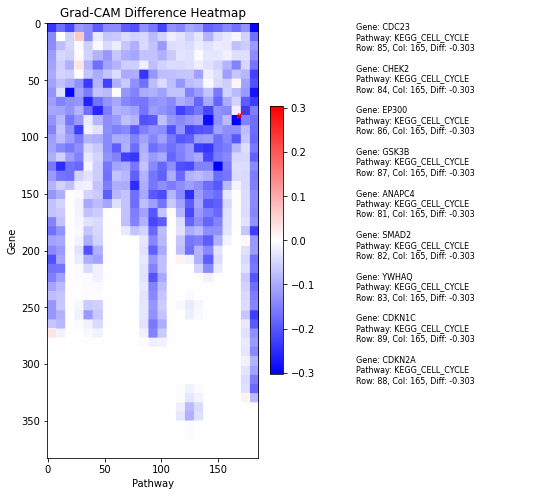

In [71]:
top_gene_diff_list = plot_diff_heatmap_with_top_genes(
    heatmap_diff,
    gene_matrix,
    pathway_list,
    top_n=9,
    save_path="./vector_image/gradcam_diff_top9_arrow1.pdf"
)

In [72]:
def get_top_positive_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=10):
    flat_idx = np.argsort(heatmap_diff.ravel())[::-1]  # 값 큰 순서
    top_coords = [np.unravel_index(i, heatmap_diff.shape) for i in flat_idx]

    results = []
    for row, col in top_coords:
        value = heatmap_diff[row, col]
        gene = gene_matrix[row][col]
        pathway = pathway_list[col]

        if value > 0 and gene and str(gene).strip() and str(pathway).strip():
            results.append((row, col, gene, pathway, value))
        if len(results) >= top_n:
            break
    return results


In [73]:
def get_top_negative_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=10):
    flat_idx = np.argsort(heatmap_diff.ravel())  # 값 작은 순서 (음수부터)
    top_coords = [np.unravel_index(i, heatmap_diff.shape) for i in flat_idx]

    results = []
    for row, col in top_coords:
        value = heatmap_diff[row, col]
        gene = gene_matrix[row][col]
        pathway = pathway_list[col]

        if value < 0 and gene and str(gene).strip() and str(pathway).strip():
            results.append((row, col, gene, pathway, value))
        if len(results) >= top_n:
            break
    return results


In [74]:
def plot_diff_heatmap_subset(heatmap_diff, gene_matrix, pathway_list, top_results, title, save_path=None):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.3)

    # Heatmap
    ax0 = plt.subplot(gs[0])
    vmax = np.max(np.abs(heatmap_diff))
    im = ax0.imshow(heatmap_diff, cmap='bwr', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
    ax0.set_title(title, fontsize=12)
    ax0.set_xlabel("Pathway")
    ax0.set_ylabel("Gene")

    # 하나만 화살표 표시
    if top_results:
        row, col, _, _, _ = top_results[0]
        ax0.annotate(
            "", xy=(col, row), xytext=(col + 10, row - 10),
            textcoords='data',
            arrowprops=dict(arrowstyle="->", color='red')
        )

    # 텍스트 영역
    ax1 = plt.subplot(gs[1])
    ax1.axis('off')
    text_lines = [
        f"Gene: {gene}\nPathway: {pathway}\nRow: {row}, Col: {col}, Diff: {value:.3f}\n"
        for row, col, gene, pathway, value in top_results
    ]
    ax1.text(0, 1, "\n".join(text_lines), va='top', ha='left', fontsize=8, wrap=True)

    if save_path:
        # PDF 저장
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path}")

        # SVG 저장 → 확장자만 바꿔서 저장
        save_path_svg = save_path.replace(".pdf", ".svg")
        plt.savefig(save_path_svg, format='svg', bbox_inches='tight')
        print(f"✅ 저장 완료: {save_path_svg}")

    plt.show()
    plt.close()


Top positive difference | Gene: ITGAL, Pathway: KEGG_CELL_ADHESION_MOLECULES_CAMS, Row: 12, Col: 24, Diff: 0.065
Top positive difference | Gene: CD274, Pathway: KEGG_CELL_ADHESION_MOLECULES_CAMS, Row: 9, Col: 24, Diff: 0.065
Top positive difference | Gene: NEIL1, Pathway: KEGG_BASE_EXCISION_REPAIR, Row: 13, Col: 31, Diff: 0.065
Top positive difference | Gene: GNMT, Pathway: KEGG_GLYCINE_SERINE_AND_THREONINE_METABOLISM, Row: 10, Col: 26, Diff: 0.065
Top positive difference | Gene: PAK2, Pathway: KEGG_ERBB_SIGNALING_PATHWAY, Row: 10, Col: 25, Diff: 0.065
Top positive difference | Gene: PDCD1LG2, Pathway: KEGG_CELL_ADHESION_MOLECULES_CAMS, Row: 10, Col: 24, Diff: 0.065
Top positive difference | Gene: NRCAM, Pathway: KEGG_CELL_ADHESION_MOLECULES_CAMS, Row: 13, Col: 24, Diff: 0.065
Top positive difference | Gene: CD28, Pathway: KEGG_CELL_ADHESION_MOLECULES_CAMS, Row: 8, Col: 24, Diff: 0.065
Top positive difference | Gene: ELK1, Pathway: KEGG_ERBB_SIGNALING_PATHWAY, Row: 8, Col: 25, Diff: 0.

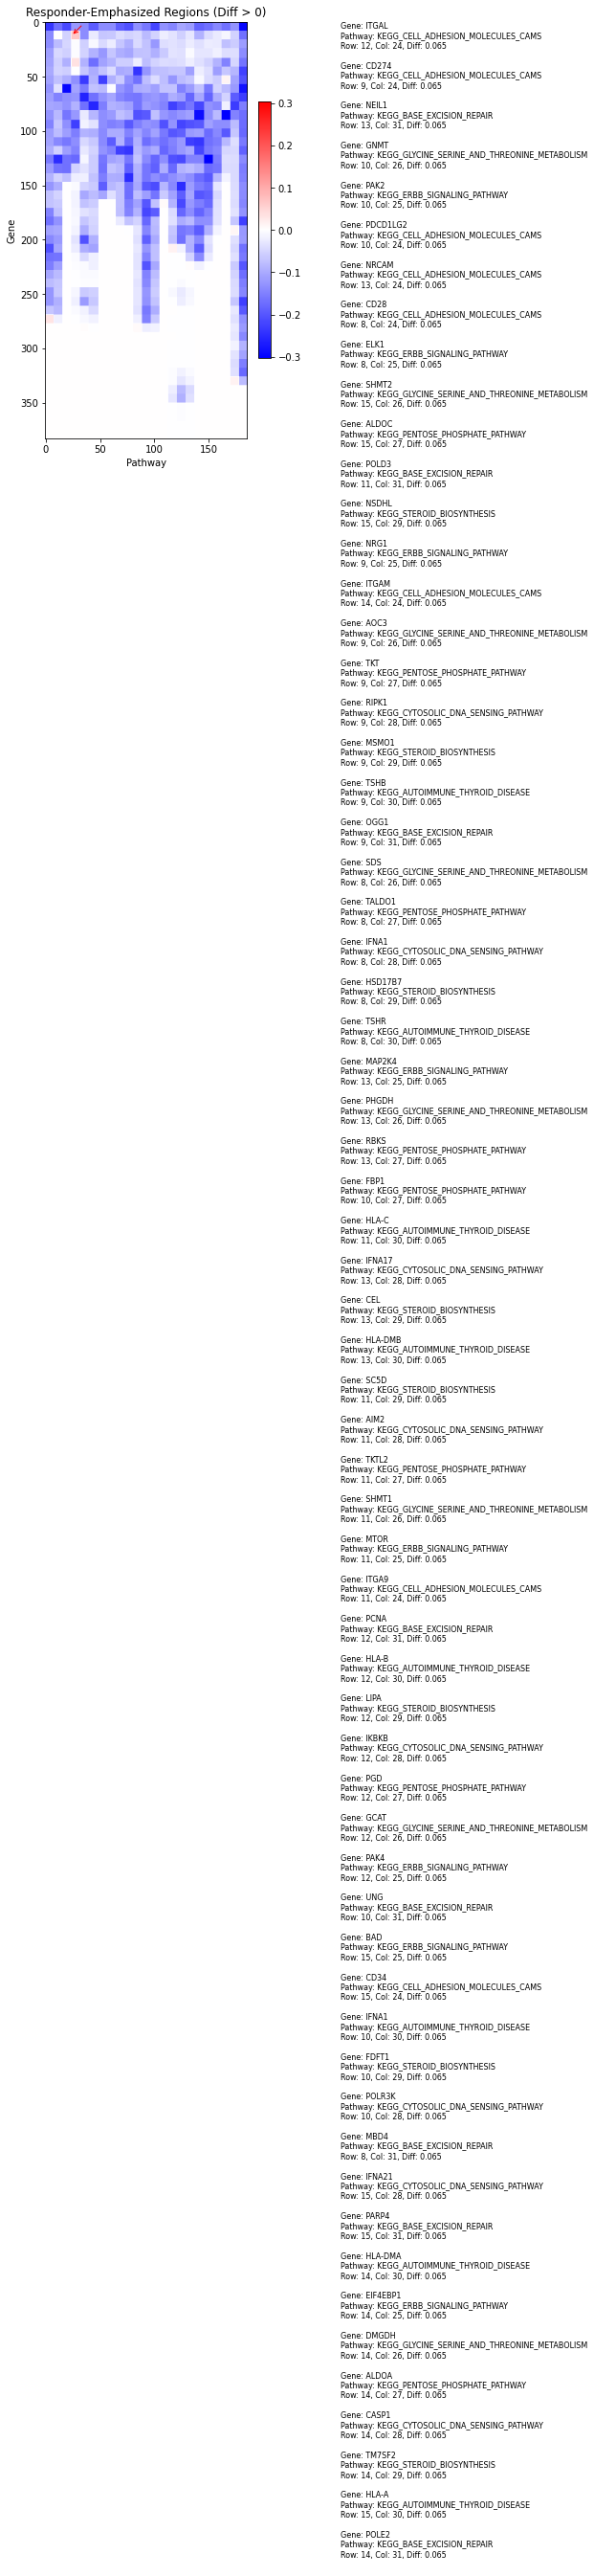

Top negative difference | Gene: YWHAQ, Pathway: KEGG_CELL_CYCLE, Row: 83, Col: 165, Diff: -0.303
Top negative difference | Gene: ANAPC4, Pathway: KEGG_CELL_CYCLE, Row: 81, Col: 165, Diff: -0.303
Top negative difference | Gene: CDKN2A, Pathway: KEGG_CELL_CYCLE, Row: 88, Col: 165, Diff: -0.303
Top negative difference | Gene: CDKN1C, Pathway: KEGG_CELL_CYCLE, Row: 89, Col: 165, Diff: -0.303
Top negative difference | Gene: SMAD2, Pathway: KEGG_CELL_CYCLE, Row: 82, Col: 165, Diff: -0.303
Top negative difference | Gene: CDC23, Pathway: KEGG_CELL_CYCLE, Row: 85, Col: 165, Diff: -0.303
Top negative difference | Gene: GSK3B, Pathway: KEGG_CELL_CYCLE, Row: 87, Col: 165, Diff: -0.303
Top negative difference | Gene: CHEK2, Pathway: KEGG_CELL_CYCLE, Row: 84, Col: 165, Diff: -0.303
Top negative difference | Gene: EP300, Pathway: KEGG_CELL_CYCLE, Row: 86, Col: 165, Diff: -0.303
✅ 저장 완료: ./vector_image/diff_top9_nonresponder.pdf
✅ 저장 완료: ./vector_image/diff_top9_nonresponder.svg


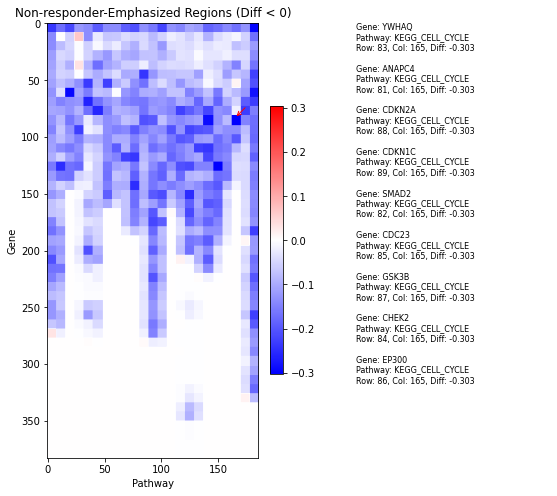

In [75]:
# Top 15 양수 영역 (Responder 강조)
top_res = get_top_positive_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=64)
for row, col, gene, pathway, value in top_res:
    print(f"Top positive difference | Gene: {gene}, Pathway: {pathway}, Row: {row}, Col: {col}, Diff: {value:.3f}")

plot_diff_heatmap_subset(
    heatmap_diff,
    gene_matrix,
    pathway_list,
    top_res,
    title="Responder-Emphasized Regions (Diff > 0)",
    save_path="./vector_image/diff_top64_responder.pdf"
)

# Top 15 음수 영역 (Non-responder 강조)
top_nonres = get_top_negative_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=9)
for row, col, gene, pathway, value in top_nonres:
    print(f"Top negative difference | Gene: {gene}, Pathway: {pathway}, Row: {row}, Col: {col}, Diff: {value:.3f}")
    
plot_diff_heatmap_subset(
    heatmap_diff,
    gene_matrix,
    pathway_list,
    top_nonres,
    title="Non-responder-Emphasized Regions (Diff < 0)",
    save_path="./vector_image/diff_top9_nonresponder.pdf"
)
